In [1]:
from sched import scheduler

import polars as pl
import polars.selectors as cs
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch
import torch.nn as nn
from torch.nn import  functional as F
from torch.utils.data import DataLoader, TensorDataset
import copy

# for getting summary info on models
from torchsummary import summary

pl.Config.set_tbl_cols(-1)

polars.config.Config

In [2]:
# import the MNIST data
raw_data = pl.read_csv("../convolution/mnist_train_small.csv")

# separate into features and labels
data = raw_data[:, 1:]
label = raw_data[:, 0]

In [3]:
# split the data before scaling
X_train, X_test, y_train, y_test = train_test_split(data, label, test_size=0.2, random_state=42)

In [4]:
# normalize the data to [0, 1]
minmax_scaler = MinMaxScaler()

X_train_scaled = minmax_scaler.fit_transform(X_train)
X_test_scaled = minmax_scaler.transform(X_test)

In [5]:
# before reshape
print(f'Train Shape before reshaping: {X_train_scaled.shape}')
print(f'Test Shape before reshaping: {X_test_scaled.shape}')

# reshape to 2D
X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], 1, 28, 28)
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], 1, 28, 28)

# check the shape after reshaping to 2D
print(f'Train Data Shape: {X_train_scaled.shape}')
print(f'Test Data Shape: {X_test_scaled.shape}')

Train Shape before reshaping: (15999, 784)
Test Shape before reshaping: (4000, 784)
Train Data Shape: (15999, 1, 28, 28)
Test Data Shape: (4000, 1, 28, 28)


In [6]:
# convert to tensors
# torch.long is the same for torch.int64
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [7]:
# convert to pytorch dataset
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

In [8]:
# check size
train_data.tensors[0].shape

torch.Size([15999, 1, 28, 28])

In [9]:
# translate to dataloader object
batchsize = 32
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [10]:
class mnistModel(nn.Module):
    def __init__(self, printtoggle=False, activation='relu'):
        super().__init__()

        # activation map
        activation_map = {
            'relu': nn.ReLU,
            'tanh': nn.Tanh,
            'sigmoid': nn.Sigmoid,
            'leakyrelu': nn.LeakyReLU
        }

        # get the activation class from the dictionary
        act_fn = activation_map.get(activation.lower(), nn.ReLU)

        # convolutional layers
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=5, stride=1, padding=1),
            nn.MaxPool2d(2),
            act_fn(),
            nn.Conv2d(10, 20, kernel_size=5, stride=1, padding=1),
            nn.MaxPool2d(2),
            act_fn()
        )

        # automatically calculate the flattened size using a dummy forward pass
        dummy_input = torch.zeros(1, 1, 28, 28)  # batch_size=1, channels=1, height=28, width=28
        conv_output = self.conv_layers(dummy_input)
        flattened_size = conv_output.view(1, -1).shape[1]

        # manual way of calculating
        # compute the number of units in FC layer (number of outputs of conv2)
        # after conv1: (28+2*1-5)/1 + 1 = 26, then /2 from maxpool = 13
        # after conv2: (13+2*1-5)/1 + 1 = 11, then /2 from maxpool = 5
        # expectSize = 20 * 5 * 5  # 20 channels, 5x5 spatial dimensions

        # fully-connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(flattened_size, 50),
            act_fn(),
            nn.Linear(50, 10)
        )

        # toggle for printing
        self.print = printtoggle

    def forward(self, x):
        if self.print:
            print(f'Input: {x.shape}')

        x = self.conv_layers(x)
        if self.print:
            print(f'After conv layers: {x.shape}')

        # this reshapes or flattens the tensors from a 4D conv output to a 2D tensor suitable for fully-connected layers
        # x.shape[0] is the batch size (number of images)
        # -1 figures out this dimension automatically
        ## it automatically calculates: 20 x 5 x 5
        x = x.view(x.shape[0], -1)
        if self.print:
            print(f'Vectorize: {x.shape}')

        x = self.fc_layers(x)
        if self.print:
            print(f'Output: {x.shape}')

        return x

### Calculation Note
1. Input: 28x2*
2. After conv1 (kernel=5, padding=1, stride=1)
    * (28 + 2x1) /1 + 1 = 26x26
3. After maxpool1 (kernel=2, stride=2)
    * 26/2 = 13x13
4. After conv2 (kernel=5, padding=1, stride=1)
    * (13 + 2*1 -5) /1+1 = 11 x11
5. Aftermaxpool2 (kernel=2, stride=2)
    * 11*2 = 5x5 (with floor division)

output_height = floor((input_height + 2*padding_height - kernel_height) / stride_height) + 1
output_width = floor((input_width + 2*padding_width - kernel_width) / stride_width) + 1

In [11]:
# test the mode
mnistModel()

mnistModel(
  (conv_layers): Sequential(
    (0): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU()
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=500, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=10, bias=True)
  )
)

In [12]:
# create rest of the components
def mnistNet(
        printtoggle=False,
        activation='relu',
        optimizer_type='adam',
        learning_rate=0.01,
        scheduler_step=10,
        scheduler_gamma=0.95
):
    loss_func = nn.CrossEntropyLoss()
    # create model
    model = mnistModel(
        printtoggle=printtoggle,
        activation=activation
    )
    # optimizer map
    optimizer_map = {
        'adam': torch.optim.Adam,
        'sgd': torch.optim.SGD,
        'rmsprop': torch.optim.RMSprop
    }
    # create optimizer
    optimizer_class = optimizer_map.get(optimizer_type.lower(), torch.optim.Adam)
    optimizer = optimizer_class(model.parameters(), lr=learning_rate)
    # scheduler setup
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=scheduler_step,
        gamma=scheduler_gamma,
    )
    return model, loss_func, optimizer, scheduler


In [13]:
# train the model
def trainModel(
        numepochs=100,
        train_loader=train_loader,
        test_loader=test_loader,
        printtoggle=True,
        toggledynamic=False
):
    training_progress = pl.DataFrame(
        schema=[
            ('iteration', pl.Int64),
            ('epoch', pl.Int64),
            ('train_loss', pl.Float64),
            ('train_acc', pl.Float64),
            ('test_loss', pl.Float64),
            ('test_acc', pl.Float64)
        ]
    )
    iteration = 0
    # create model
    model, loss_func, optimizer, scheduler = mnistNet(
        printtoggle=printtoggle,
        activation='relu',
        optimizer_type='adam',
        learning_rate=0.01,
        scheduler_step=10,
        scheduler_gamma=0.95,
    )
    # set the patience to stop optimization when convergence
    patience = 15
    best_loss = float('inf')
    no_improve_count = 0
    best_model = None

    # start the training loop
    for epoch in range(numepochs):
        # initialize the train loss and num batches
        epoch_train_loss = 0
        epoch_train_acc = 0
        num_batches = 0

        for inputs, targets in train_loader:
            # forward pass and loss
            yHat = model(inputs)
            loss = loss_func(yHat, targets)
            # backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # evaluate training accuracy
            train_matches = (torch.argmax(yHat, axis=1) == targets).float()
            train_acc = 100 * torch.mean(train_matches)
            # append the loss and accuracy
            epoch_train_loss += loss.item()
            epoch_train_acc += train_acc.item()
            num_batches += 1
            iteration += 1

        # update learning rate after all batches (once per epoch)
        if toggledynamic:
            scheduler.step()
            current_lrs = scheduler.get_last_lr()[0]
        else:
            current_lrs = optimizer.param_groups[0]['lr']


        avg_train_loss = epoch_train_loss / num_batches
        avg_train_acc = epoch_train_acc / num_batches

        # evaluate test set
        model.eval()
        test_loss_total = 0
        test_acc_total = 0
        test_batches = 0
        with torch.no_grad():
            for X_testTL, y_testTL in test_loader:
                yHat_test = model(X_testTL)
                test_loss = loss_func(yHat_test, y_testTL)
                # get test accuracy
                test_matches = (torch.argmax(yHat_test, axis=1) == y_testTL).float()
                test_acc =  (100 * torch.mean(test_matches))
                test_loss_total += test_loss.item()
                test_acc_total += test_acc.item()
                test_batches += 1

        avg_test_loss = test_loss_total / test_batches
        avg_test_acc = test_acc_total / test_batches

        # create new row to annotate the data
        new_row = pl.DataFrame([{
            'iteration': iteration,
            'epoch': epoch,
            'train_loss': avg_train_loss,
            'train_acc' : avg_train_acc,
            'test_loss' : avg_test_loss,
            'test_acc' : avg_test_acc
        }])

        # concat the new row into the dataframe
        training_progress = pl.concat([training_progress, new_row])

        # early stopping logic
        if avg_train_loss < best_loss:
            best_loss = avg_train_loss
            no_improve_count = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            no_improve_count += 1

        # check early stopping condition
        if no_improve_count >= patience or epoch > 20:
            print(f"Early stopping at epoch {epoch}")
            model.load_state_dict(best_model)
            break

    return training_progress, model, best_loss



In [14]:
# test the model
training_progress, model, best_loss = trainModel(numepochs=30, train_loader=train_loader, test_loader=test_loader, toggledynamic=False, printtoggle=False)

Early stopping at epoch 21


In [15]:
# check the table
training_progress.head()

iteration,epoch,train_loss,train_acc,test_loss,test_acc
i64,i64,f64,f64,f64,f64
499,0,0.243798,92.190631,0.129234,96.300003
998,1,0.100712,96.943888,0.159821,95.800003
1497,2,0.083484,97.526303,0.140076,96.350006
1996,3,0.072131,97.920842,0.186305,96.224998
2495,4,0.0794,97.745491,0.219259,96.599998


/opt/anaconda3/envs/py312/lib/python3.12/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'fill' aesthetic. Make sure you have mapped a variable to it


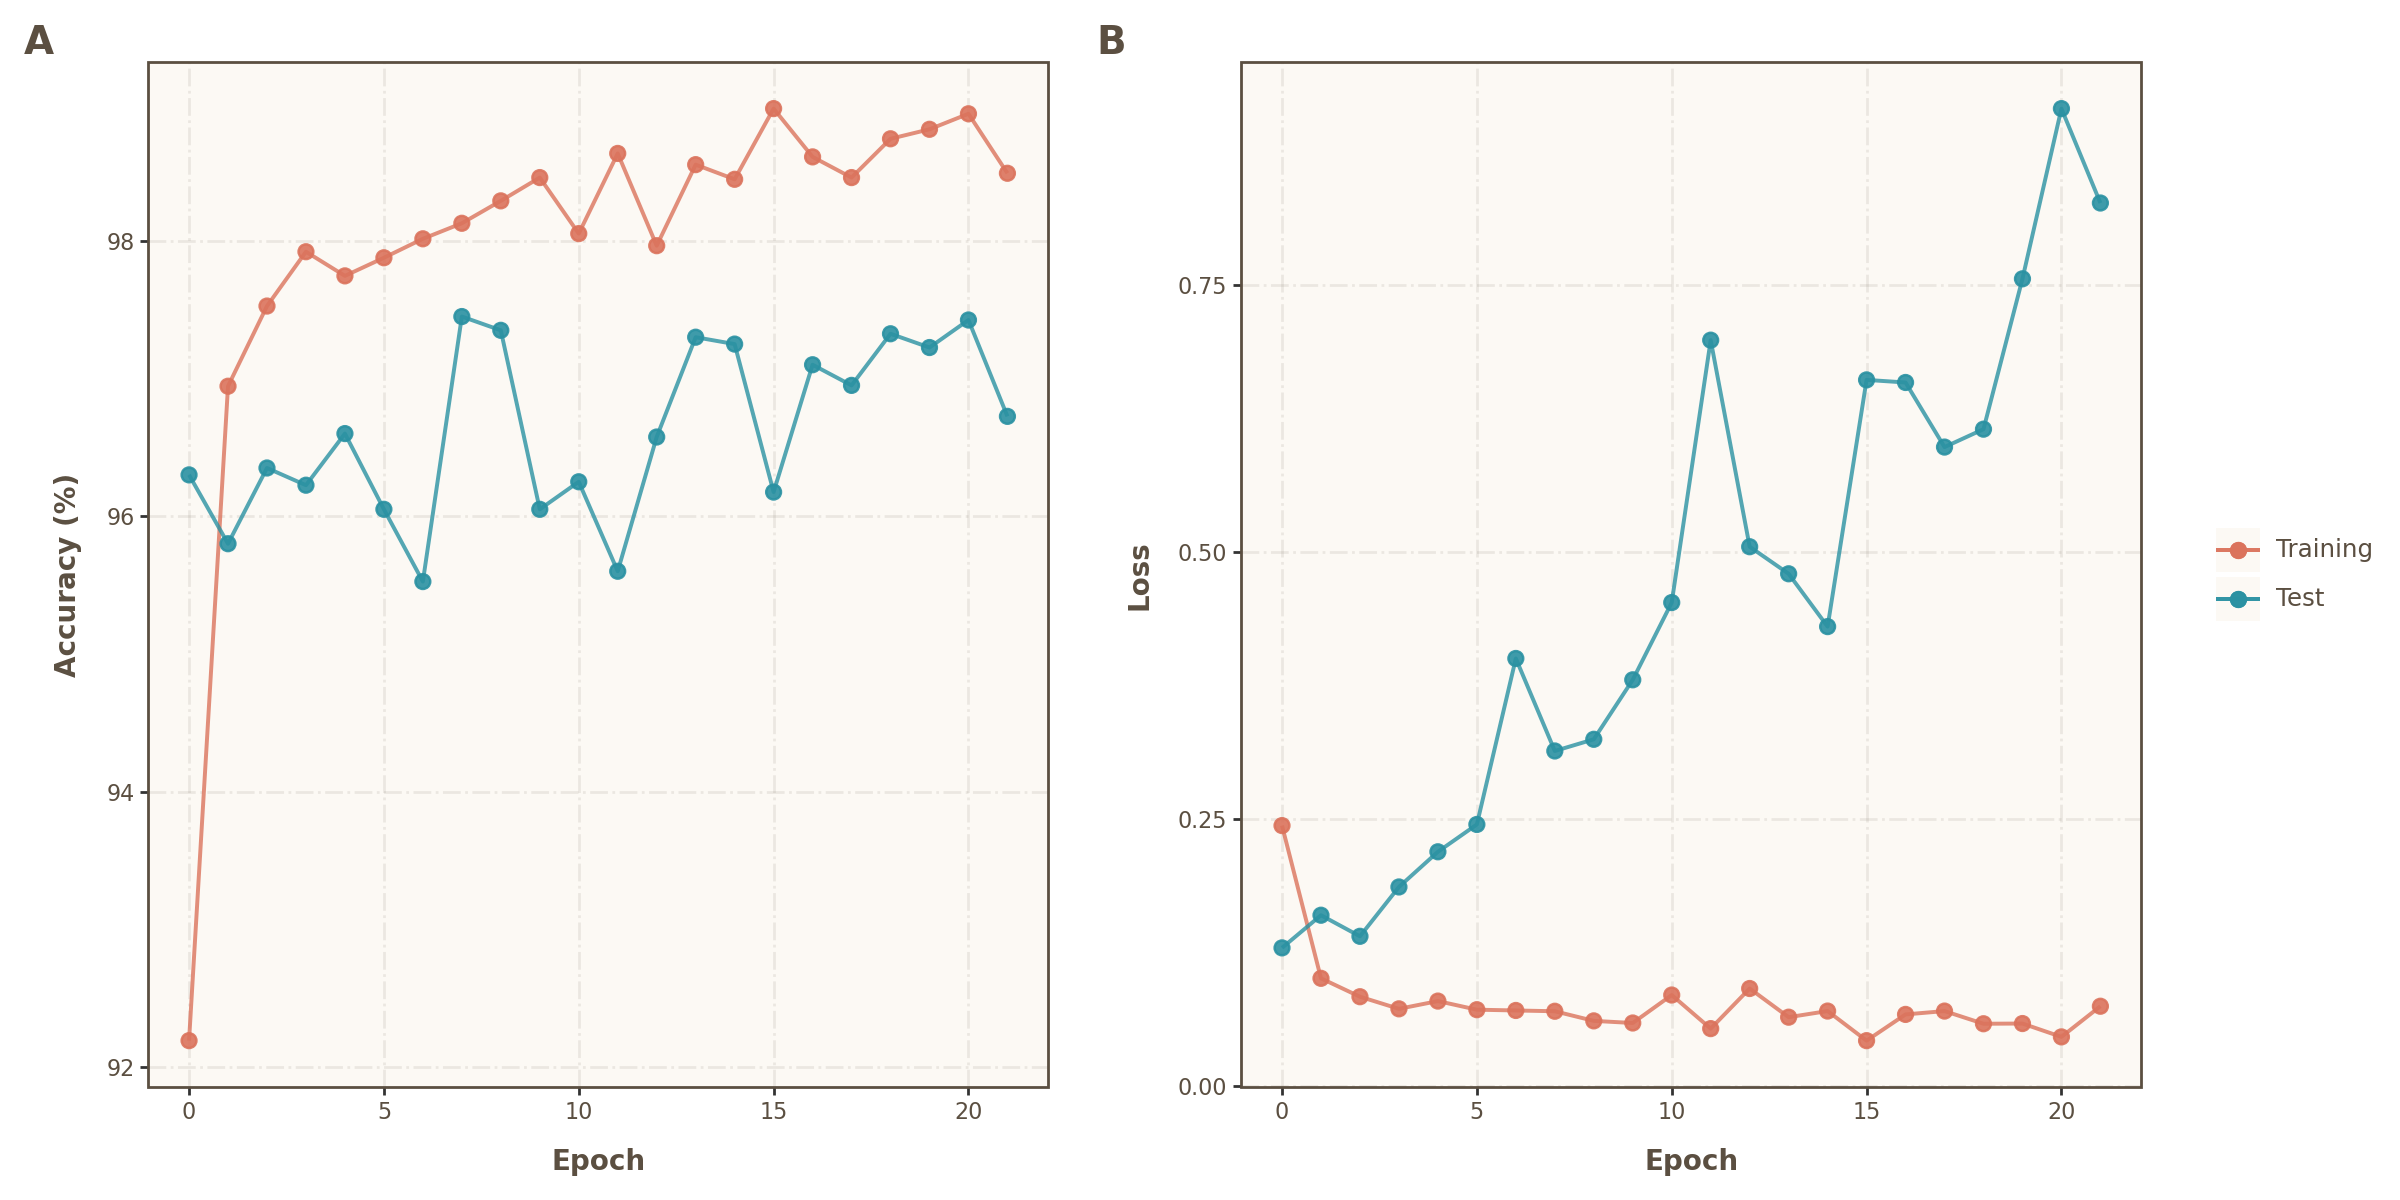

In [16]:
c1, c2 = "#5B4F41", "#FCF9F4"

theme_set(
    theme_gray()
    + theme(
        figure_size=(12, 6),
        text=element_text(color=c1),
        legend_position="none",
        panel_background=element_rect(fill=c2),
        panel_grid_major=element_line(color=c1, linetype="dashdot", alpha=0.1),
        panel_grid_minor=element_blank(),
        panel_border=element_rect(color=c1),
        axis_text=element_text(size=8),
        strip_text=element_text(color="white"),
        strip_background=element_rect(fill=c1, color=c1)
    )
)

# Use the same scale for the color and fill aesthetics
scale_color_and_fill = scale_color_manual(
    values=["#DB735C", "#2A91A2", "#F8B75A"],
    aesthetics=("fill", "color")
)

# review the performance metrics
p1 = (
    ggplot(training_progress, aes(x='epoch'))
    + geom_line(aes(y='train_acc', color='"Training"'), size=0.8, alpha=0.8)
    + geom_point(aes(y='train_acc', color='"Training"'), size=2.5, alpha=0.9)
    + geom_line(aes(y='test_acc', color='"Test"'), size=0.8, alpha=0.8)
    + geom_point(aes(y='test_acc', color='"Test"'), size=2.5, alpha=0.9)
    + labs(
        x='Epoch',
        y='Accuracy (%)',
        tag='A'
    )
    + scale_color_and_fill
    # + scale_color_manual(values={'Training': '#2E86AB', 'Test': '#E63946'})
    # + theme_minimal()
    + theme(
        legend_position='none',
        legend_title=element_blank(),
        plot_tag=element_text(size=14, weight='bold'),
        axis_title=element_text(size=10, weight='bold'),
        panel_grid_minor=element_blank()
    )
)

p2 = (
    ggplot(training_progress, aes(x='epoch'))
    + geom_line(aes(y='train_loss', color='"Training"'), size=0.8, alpha=0.8)
    + geom_point(aes(y='train_loss', color='"Training"'), size=2.5, alpha=0.9)
    + geom_line(aes(y='test_loss', color='"Test"'), size=0.8, alpha=0.8)
    + geom_point(aes(y='test_loss', color='"Test"'), size=2.5, alpha=0.9)
    + labs(
        x='Epoch',
        y='Loss',
        tag='B'
    )
    + scale_color_and_fill
    # + scale_color_manual(values={'Training': '#2E86AB', 'Test': '#E63946'})
    # + theme_minimal()
    + theme(
        legend_position='right',
        legend_title=element_blank(),
        plot_tag=element_text(size=14, weight='bold'),
        axis_title=element_text(size=10, weight='bold'),
        panel_grid_minor=element_blank(),
    )
)

# Combine plots side by side
p1 | p2


In [17]:
# test the model with one batvh
train_one_batch = next(iter(train_loader))
test_one_batch = next(iter(test_loader))

# Wrap single batches in a list so they can be iterated
train_one_batch_loader = [train_one_batch]
test_one_batch_loader = [test_one_batch]

# training_progress, model, best_loss = trainModel(
#     numepochs=30,
#     train_loader=train_one_batch_loader,
#     test_loader=test_one_batch_loader,
#     toggledynamic=False,
#     printtoggle=True
# )

In [18]:
# count the total number of parameters in the model
summary(model,(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 26, 26]             260
         MaxPool2d-2           [-1, 10, 13, 13]               0
              ReLU-3           [-1, 10, 13, 13]               0
            Conv2d-4           [-1, 20, 11, 11]           5,020
         MaxPool2d-5             [-1, 20, 5, 5]               0
              ReLU-6             [-1, 20, 5, 5]               0
            Linear-7                   [-1, 50]          25,050
              ReLU-8                   [-1, 50]               0
            Linear-9                   [-1, 10]             510
Total params: 30,840
Trainable params: 30,840
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.10
Params size (MB): 0.12
Estimated Total Size (MB): 0.22
---------------------------------------------

In [19]:
# !jupyter nbconvert --to html CNN-MNIST-polars.ipynb

[NbConvertApp] Converting notebook CNN-MNIST-polars.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 605064 bytes to CNN-MNIST-polars.html
